# NB3b — So sánh các biến thể: DPO · RPO · DPO chuẩn hoá độ dài · LD-DPO · ORPO (TUỲ CHỌN, +8)

Cùng dữ liệu (`VARIANT_TRAIN` cặp đầu của NB2), cùng số bước, cùng LoRA. Chỉ đổi loss.

| Run | Cấu hình TRL | Ý tưởng |
|---|---|---|
| `dpo` | `loss_type=["sigmoid"]` | mức cơ sở (baseline) |
| `rpo` | `loss_type=["sigmoid","sft"]` | thêm NLL trên chosen, chống likelihood displacement |
| `dpo_norm` | `loss_type=["sigmoid_norm"]` | log-prob trung bình theo token (gần SimPO nhưng vẫn có reference) |
| `ld_dpo` | `ld_alpha=0.5` | giảm trọng số phần token vượt quá độ dài chung (LD-DPO) |
| `orpo` | `trl.experimental.orpo` | không reference, SFT + odds-ratio trong một bước |

ORPO thường xuất phát từ mô hình *chưa* SFT; ở đây nó chạy trên cùng `models/sft-merged`
để bảng so sánh chỉ khác nhau ở loss. Đặt `ORPO_FROM_BASE=1` để thử ORPO từ base.

**Đọc kết quả:** độ chính xác reward trên held-out và độ dài đầu ra trung bình. Các
biến thể có thang reward khác nhau, nên **không so trực tiếp giá trị margin** giữa các dòng.

In [1]:
import os
import sys
from pathlib import Path

ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "lab22" / "config.py").exists())
sys.path.insert(0, str(ROOT))

import unsloth  # noqa: F401
import torch

from lab22 import config as C
from lab22 import modeling as MD

assert torch.cuda.is_available()
assert C.SFT_MERGED.exists() and (C.PREF_DIR / "train.parquet").exists(), "Run NB1 + NB2 first"
C.ensure_dirs()
C.VARIANTS_DIR.mkdir(parents=True, exist_ok=True)

from datasets import Dataset

train_ds = Dataset.from_parquet(str(C.PREF_DIR / "train.parquet"))
train_ds = train_ds.select(range(min(C.TIER.variant_train, len(train_ds))))
assert len(train_ds) > 0, "Empty preference train split: rerun NB2"
eval_ds = Dataset.from_parquet(str(C.PREF_DIR / "eval.parquet"))
probe_prompts = [r["prompt"][0]["content"] for r in eval_ds.select(range(min(20, len(eval_ds))))]
print(f"variant train={len(train_ds)} eval={len(eval_ds)} probe prompts={len(probe_prompts)}")

RUNS = {
    "dpo": {"loss_type": ["sigmoid"]},
    "rpo": {"loss_type": ["sigmoid", "sft"], "loss_weights": [1.0, 1.0]},
    "dpo_norm": {"loss_type": ["sigmoid_norm"]},
    "ld_dpo": {"loss_type": ["sigmoid"], "ld_alpha": 0.5},
}
SELECTED = [r for r in os.environ.get("VARIANTS", "dpo,rpo,dpo_norm,ld_dpo,orpo").split(",") if r]

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.


🦥 Unsloth Zoo will now patch everything to make training faster!


variant train=300 eval=100 probe prompts=20


## 1. Các biến thể dựa trên DPOTrainer

In [2]:
import json

from trl import DPOTrainer

results = {}
for name in [r for r in SELECTED if r in RUNS]:
    print(f"\n=== {name} ===")
    model, tokenizer = MD.load_model(C.SFT_MERGED)
    model = MD.add_lora(model)
    overrides = dict(RUNS[name])
    loss_type = overrides.pop("loss_type")
    trainer = DPOTrainer(
        model=model,
        args=MD.dpo_config(C.VARIANTS_DIR / f"{name}-ckpt", loss_type=loss_type, eval_strategy="no", **overrides),
        train_dataset=train_ds,
        eval_dataset=eval_ds,
        processing_class=tokenizer,
    )
    trainer.train()
    ev = trainer.evaluate()
    outputs = MD.generate(trainer.model, tokenizer, probe_prompts, max_new_tokens=256)
    results[name] = {
        "eval_reward_accuracy": ev.get("eval_rewards/accuracies"),
        "eval_chosen_reward": ev.get("eval_rewards/chosen"),
        "eval_rejected_reward": ev.get("eval_rewards/rejected"),
        "eval_reward_gap": ev.get("eval_rewards/margins"),
        "mean_output_chars": sum(map(len, outputs)) / len(outputs),
        "diagnosis": MD.diagnose(MD.reward_history(trainer.state.log_history))[0],
    }
    trainer.model.save_pretrained(str(C.VARIANTS_DIR / name))
    tokenizer.save_pretrained(str(C.VARIANTS_DIR / name))
    from lab22 import data as D
    D.save_split_fingerprint(C.PREF_DIR, C.VARIANTS_DIR / name)
    (C.VARIANTS_DIR / "variants_summary.json").write_text(json.dumps(results, indent=2), encoding="utf-8")
    print(results[name])
    del trainer, model
    MD.cleanup()


=== dpo_norm ===


==((====))==  Unsloth 2026.10.2: Fast Qwen3 patching. Transformers: 5.17.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.11.0+cu130. CUDA: 7.5. CUDA Toolkit: 13.0. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

The tokenizer you are loading from '/content/lab22-runtime/models/sft-merged' with an incorrect regex pattern: https://huggingface.co/mistralai/Mistral-Small-3.1-24B-Instruct-2503/discussions/84#69121093e8b480e709447d5e. This will lead to incorrect tokenization. You should set the `fix_mistral_regex=True` flag when loading this tokenizer to fix this issue.


The tokenizer you are loading from '/content/lab22-runtime/models/sft-merged' with an incorrect regex pattern: https://huggingface.co/mistralai/Mistral-Small-3.1-24B-Instruct-2503/discussions/84#69121093e8b480e709447d5e. This will lead to incorrect tokenization. You should set the `fix_mistral_regex=True` flag when loading this tokenizer to fix this issue.


...

Both `max_new_tokens` (=256) and `max_length`(=262144) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Both `max_new_tokens` (=256) and `max_length`(=262144) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Both `max_new_tokens` (=256) and `max_length`(=262144) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Unsloth: Restored added_tokens_decoder metadata in /content/drive/MyDrive/Lab22_PhamHoangTrong_2A202602765/adapters/variants/ld_dpo/tokenizer_config.json.


{'eval_reward_accuracy': 0.56, 'eval_chosen_reward': -0.12407880625891267, 'eval_rejected_reward': -0.14641781709506177, 'eval_reward_gap': 0.022339010834693907, 'mean_output_chars': 461.35, 'diagnosis': 'LIKELIHOOD DISPLACEMENT'}


## 2. ORPO (không reference)

In [3]:
if "orpo" in SELECTED:
    from trl.experimental.orpo import ORPOConfig, ORPOTrainer

    start = C.BASE_MODEL if os.environ.get("ORPO_FROM_BASE") == "1" else C.SFT_MERGED
    model, tokenizer = MD.load_model(start)
    model = MD.add_lora(model)
    orpo_args = ORPOConfig(
        output_dir=str(C.VARIANTS_DIR / "orpo-ckpt"),
        per_device_train_batch_size=C.TIER.dpo_batch,
        per_device_eval_batch_size=C.TIER.dpo_batch,
        gradient_accumulation_steps=C.TIER.dpo_grad_accum,
        num_train_epochs=C.DPO_EPOCHS,
        learning_rate=C.DPO_LR,
        beta=0.1,  # λ in the paper
        max_length=C.MAX_LEN,
        warmup_steps=0.1,
        lr_scheduler_type="cosine",
        logging_steps=5,
        save_strategy="no",
        optim="adamw_8bit",
        seed=C.SEED,
        report_to="none",
        **MD.precision_flags(),
    )
    trainer = ORPOTrainer(
        model=model, args=orpo_args, train_dataset=train_ds, eval_dataset=eval_ds, processing_class=tokenizer
    )
    trainer.train()
    ev = trainer.evaluate()
    outputs = MD.generate(trainer.model, tokenizer, probe_prompts, max_new_tokens=256)
    results["orpo"] = {
        "start": str(start),
        "eval_reward_accuracy": ev.get("eval_rewards/accuracies"),
        "eval_log_odds_ratio": ev.get("eval_log_odds_ratio"),
        "eval_reward_gap": ev.get("eval_rewards/margins"),
        "mean_output_chars": sum(map(len, outputs)) / len(outputs),
    }
    trainer.model.save_pretrained(str(C.VARIANTS_DIR / "orpo"))
    tokenizer.save_pretrained(str(C.VARIANTS_DIR / "orpo"))
    print(results["orpo"])
    del trainer, model
    MD.cleanup()

==((====))==  Unsloth 2026.10.2: Fast Qwen3 patching. Transformers: 5.17.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.11.0+cu130. CUDA: 7.5. CUDA Toolkit: 13.0. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

The tokenizer you are loading from '/content/lab22-runtime/models/sft-merged' with an incorrect regex pattern: https://huggingface.co/mistralai/Mistral-Small-3.1-24B-Instruct-2503/discussions/84#69121093e8b480e709447d5e. This will lead to incorrect tokenization. You should set the `fix_mistral_regex=True` flag when loading this tokenizer to fix this issue.


The tokenizer you are loading from '/content/lab22-runtime/models/sft-merged' with an incorrect regex pattern: https://huggingface.co/mistralai/Mistral-Small-3.1-24B-Instruct-2503/discussions/84#69121093e8b480e709447d5e. This will lead to incorrect tokenization. You should set the `fix_mistral_regex=True` flag when loading this tokenizer to fix this issue.


Unsloth for ORPO_TRAINER is not yet implemented! Just ignore this function.
We support: `['base_trainer', 'distillation_trainer', 'dpo_trainer', 'grpo_trainer', 'kto_trainer', 'reward_trainer', 'rloo_trainer', 'sft_trainer']`


...

Both `max_new_tokens` (=256) and `max_length`(=262144) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Both `max_new_tokens` (=256) and `max_length`(=262144) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Both `max_new_tokens` (=256) and `max_length`(=262144) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Unsloth: Restored added_tokens_decoder metadata in /content/drive/MyDrive/Lab22_PhamHoangTrong_2A202602765/adapters/variants/orpo/tokenizer_config.json.


{'start': '/content/lab22-runtime/models/sft-merged', 'eval_reward_accuracy': 0.6600000262260437, 'eval_log_odds_ratio': -0.6239340901374817, 'eval_reward_gap': 0.015246884897351265, 'mean_output_chars': 467.4}


## 3. Bảng tổng hợp (sản phẩm nộp `03b-variants.png`)

         eval_reward_accuracy eval_chosen_reward eval_rejected_reward eval_reward_gap mean_output_chars                diagnosis                                     start eval_log_odds_ratio
dpo_norm                 0.64          -0.177115             -0.18643        0.009315            458.65  LIKELIHOOD DISPLACEMENT                                       NaN                 NaN
ld_dpo                   0.56          -0.124079            -0.146418        0.022339            461.35  LIKELIHOOD DISPLACEMENT                                       NaN                 NaN
orpo                     0.66                NaN                  NaN        0.015247             467.4                      NaN  /content/lab22-runtime/models/sft-merged           -0.623934


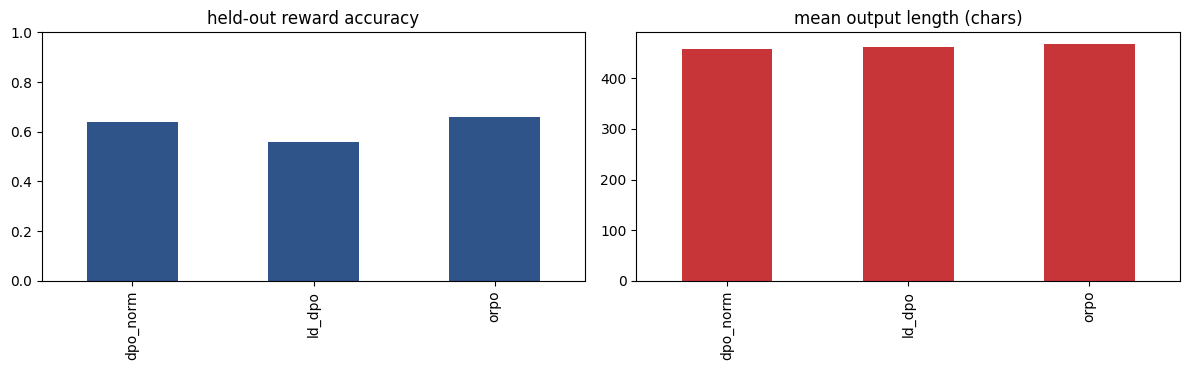

In [4]:
import matplotlib.pyplot as plt
import pandas as pd

table = pd.DataFrame(results).T
print(table.to_string())
(C.VARIANTS_DIR / "variants_summary.json").write_text(json.dumps(results, indent=2, default=str))

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
table["eval_reward_accuracy"].astype(float).plot.bar(ax=axes[0], color="#2e548a")
axes[0].set_ylim(0, 1)
axes[0].set_title("held-out reward accuracy")
table["mean_output_chars"].astype(float).plot.bar(ax=axes[1], color="#c83538")
axes[1].set_title("mean output length (chars)")
fig.tight_layout()
fig.savefig(C.SCREENSHOTS / "03b-variants.png", dpi=120, bbox_inches="tight")
plt.show()

## 4. Câu hỏi cho REFLECTION

1. Biến thể nào làm đầu ra dài ra nhiều nhất? Có khớp với tỉ lệ "chosen dài hơn" ở NB2 không?
2. RPO có giữ `rewards/chosen` dương trong khi DPO thì không? (so với chẩn đoán NB3)
3. Độ chính xác reward cao hơn có nghĩa là mô hình tốt hơn không? Chạy giám khảo ở NB4 trên
   adapter `adapters/variants/<name>` (đặt `DPO_ADAPTER_OVERRIDE`) để kiểm tra.